# 01 - Exploratory Data Analysis

**Project:** Credit card fraud prediction MVP.

**What this notebook does:** downloads the raw transaction dataset, loads it into a
DataFrame, and describes what is in it. No cleaning or modeling happens here. The
goal is to understand the data well enough to plan the wrangling and modeling
steps that follow.

**Dataset:** the Capital One Data Science recruiting dataset of synthetic credit
card transactions, published at
`https://github.com/CapitalOneRecruiting/DS`. It is synthetic data built for a
take-home exercise, so it is safe to share and has no real customer information.


## 1. Get the data

The steps below download `transactions.zip` straight from the public GitHub repo,
unzip it into `data/raw/`, and report what came out. `data/raw/` is gitignored,
so the data itself is never committed. Anyone who clones this repo and runs this
notebook rebuilds the dataset from scratch.


In [1]:
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Resolve data/raw/ relative to the repo root, whether this runs from the repo
# root or from notebooks/.
CWD = Path.cwd()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
RAW_DIR = REPO_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATA_URL = "https://github.com/CapitalOneRecruiting/DS/raw/master/transactions.zip"
ZIP_PATH = RAW_DIR / "transactions.zip"
print("Repo root :", REPO_ROOT)
print("Raw dir   :", RAW_DIR)


Repo root : C:\Users\User\Downloads\ErdosBootcamp\git\ML\04-credit-card-fraud-prediction
Raw dir   : C:\Users\User\Downloads\ErdosBootcamp\git\ML\04-credit-card-fraud-prediction\data\raw


In [2]:
import requests

if ZIP_PATH.exists():
    print(f"Zip already present: {ZIP_PATH.name} ({ZIP_PATH.stat().st_size:,} bytes)")
else:
    print(f"Downloading {DATA_URL} ...")
    resp = requests.get(DATA_URL, timeout=180)
    resp.raise_for_status()
    ZIP_PATH.write_bytes(resp.content)
    print(f"Saved {ZIP_PATH.name} ({ZIP_PATH.stat().st_size:,} bytes)")


Zip already present: transactions.zip (30,522,086 bytes)


In [3]:
# Unzip and list the contents before assuming any filename.
with zipfile.ZipFile(ZIP_PATH) as zf:
    archive_names = zf.namelist()
    print("Archive contains:", archive_names)
    zf.extractall(RAW_DIR)

extracted = [RAW_DIR / name for name in archive_names]
for path in extracted:
    print(f"  {path.name}: {path.stat().st_size:,} bytes")

DATA_PATH = extracted[0]


Archive contains: ['transactions.txt']


  transactions.txt: 609,937,737 bytes


### Load the file defensively

Public write-ups of this dataset disagree on its format. Some describe a single
JSON array, others newline-delimited JSON (one JSON object per line). The cell
below tries `json.load` first and falls back to `pd.read_json(..., lines=True)`,
then records which one actually worked.


In [4]:
load_method = None
try:
    with open(DATA_PATH, "r", encoding="utf-8") as fh:
        records = json.load(fh)
    df = pd.DataFrame(records)
    load_method = "json.load (single JSON array)"
except json.JSONDecodeError as err:
    print(f"json.load failed ({err}); falling back to newline-delimited JSON.")
    df = pd.read_json(DATA_PATH, lines=True)
    load_method = "pd.read_json(lines=True) (newline-delimited JSON)"

print("Load method that worked:", load_method)
print("Shape:", df.shape)


json.load failed (Extra data: line 2 column 1 (char 760)); falling back to newline-delimited JSON.


Load method that worked: pd.read_json(lines=True) (newline-delimited JSON)
Shape: (786363, 29)


**Finding - file format.** The file is **newline-delimited JSON**: one
transaction object per line, not one big array. `pd.read_json(path, lines=True)`
is the correct loader. This is noted here so the next person does not have to
rediscover it.


## 2. First look: size, columns, types, sample rows

In [5]:
print(f"Rows (transactions): {len(df):,}")
print(f"Columns (fields):    {df.shape[1]}")


Rows (transactions): 786,363
Columns (fields):    29


In [6]:
df.dtypes.to_frame("dtype")

,dtype
accountNumber,int64
customerId,int64
creditLimit,int64
availableMoney,float64
transactionDateTime,str
transactionAmount,float64
merchantName,str
acqCountry,str
merchantCountryCode,str
posEntryMode,str


In [7]:
df.head(5)

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,merchantCategoryCode,currentExpDate,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,echoBuffer,currentBalance,merchantCity,merchantState,merchantZip,cardPresent,posOnPremises,recurringAuthInd,expirationDateKeyInMatch,isFraud
0,737265056,737265056,5000,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,02,01,rideshare,06/2023,2015-03-14,2015-03-14,414,414,1803,PURCHASE,,0.0,,,,False,,,False,False
1,737265056,737265056,5000,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,09,01,entertainment,02/2024,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,True,,,False,False
2,737265056,737265056,5000,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,09,01,mobileapps,08/2025,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,False,,,False,False
3,737265056,737265056,5000,5000.0,2016-12-10T02:14:50,7.47,Play Store,US,US,09,01,mobileapps,08/2025,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,False,,,False,False
4,830329091,830329091,5000,5000.0,2016-03-24T21:04:46,71.18,Tim Hortons #947751,US,US,02,01,fastfood,10/2029,2015-08-06,2015-08-06,885,885,3143,PURCHASE,,0.0,,,,True,,,False,False


In [8]:
# Convert the timestamp column now so date-based summaries below are easy.
df["transactionDateTime"] = pd.to_datetime(df["transactionDateTime"])
print("Date range:", df["transactionDateTime"].min(), "to", df["transactionDateTime"].max())
print("Unique accounts:", df["accountNumber"].nunique())
print("accountNumber == customerId for every row:",
      bool((df["accountNumber"] == df["customerId"]).all()))


Date range: 2016-01-01 00:01:02 to 2016-12-30 23:59:45
Unique accounts: 5000
accountNumber == customerId for every row: True


**Finding - scale and shape.** The dataset holds **786,363 transactions**
across **5,000 accounts**, all dated within the **2016 calendar year**. Each row
has 29 fields describing the transaction, the merchant, the card, and the
account. `customerId` is identical to `accountNumber` on every row, so it carries
no extra information.


## 3. Missing values

There are two kinds of "missing" here. Standard null values (`NaN`), and fields
that are present but blank (an empty string `""`). Both are checked.


In [9]:
null_counts = df.isna().sum()
null_counts[null_counts > 0].to_frame("null_count") if null_counts.any() else "No NaN nulls in any column."


'No NaN nulls in any column.'

In [10]:
# Empty-string counts for text columns. pandas may store these as the
# "object", "string", or newer "str" dtype, so test with is_string_dtype.
text_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c].dtype)]
empty_counts = {c: int((df[c] == "").sum()) for c in text_cols}
empty_counts = {c: n for c, n in empty_counts.items() if n > 0}
empty_df = (
    pd.Series(empty_counts, name="empty_string_count")
    .sort_values(ascending=False)
    .to_frame()
)
empty_df["pct_of_rows"] = (empty_df["empty_string_count"] / len(df)).map("{:.1%}".format)
empty_df


,empty_string_count,pct_of_rows
merchantZip,786363,100.0%
echoBuffer,786363,100.0%
merchantCity,786363,100.0%
posOnPremises,786363,100.0%
recurringAuthInd,786363,100.0%
merchantState,786363,100.0%
acqCountry,4562,0.6%
posEntryMode,4054,0.5%
merchantCountryCode,724,0.1%
transactionType,698,0.1%


**Finding - missing data.** No column has a true `NaN` null. But six columns
are blank on **every single row**: `echoBuffer`, `merchantCity`,
`merchantState`, `merchantZip`, `posOnPremises`, `recurringAuthInd`. These are
placeholder fields with no data and will be dropped before modeling.

A second, much smaller group is blank on a fraction of a percent of rows:
`acqCountry` (0.6%), `posEntryMode` (0.5%), and `merchantCountryCode`,
`posConditionCode`, `transactionType` (each about 0.1%). These are the real gaps
that will need a simple fill during wrangling.


## 4. Numeric fields: ranges, and which "numbers" are really identifiers

Several columns are stored as numbers but are actually codes or IDs. Taking an
average of an account number is meaningless. They are separated out here.


In [11]:
identifier_like = ["accountNumber", "customerId", "cardCVV", "enteredCVV", "cardLast4Digits"]
true_numeric = ["creditLimit", "availableMoney", "transactionAmount", "currentBalance"]

print("Treated as identifiers (codes, not magnitudes):", identifier_like)
print("Treated as true numeric measures            :", true_numeric)


Treated as identifiers (codes, not magnitudes): ['accountNumber', 'customerId', 'cardCVV', 'enteredCVV', 'cardLast4Digits']
Treated as true numeric measures            : ['creditLimit', 'availableMoney', 'transactionAmount', 'currentBalance']


In [12]:
df[true_numeric].describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]]

,min,25%,50%,75%,max,mean,std
creditLimit,250.00,5000.00,7500.00,15000.000,50000.00,10759.464459,11636.174890
availableMoney,-1005.63,1077.42,3184.86,7500.000,50000.00,6250.725369,8880.783989
transactionAmount,0.00,33.65,87.90,191.480,2011.54,136.985791,147.725569
currentBalance,0.00,689.91,2451.76,5291.095,47498.81,4508.739089,6457.442068


In [13]:
# Unique-value counts across every column, to separate low-cardinality
# categories from high-cardinality IDs / free text.
df.nunique().sort_values().to_frame("n_unique")


,n_unique
merchantCity,1
merchantState,1
posOnPremises,1
recurringAuthInd,1
merchantZip,1
echoBuffer,1
cardPresent,2
expirationDateKeyInMatch,2
isFraud,2
posConditionCode,4


**Finding - fields worth modeling on.** The genuine numeric measures are
`transactionAmount`, `creditLimit`, `availableMoney`, and `currentBalance`.
`creditLimit` takes only 10 distinct values, so it behaves like a banded
category. The low-cardinality categorical fields are `transactionType`,
`merchantCategoryCode` (19 real categories), `posEntryMode`, `posConditionCode`,
`acqCountry`, and `merchantCountryCode`. `merchantName` has about 2,500 distinct
values and is closer to free text. The account and card number columns are
identifiers and should not be fed to a model as raw numbers.


## 5. Categorical fields: what values appear

In [14]:
for col in ["transactionType", "merchantCategoryCode", "posEntryMode",
            "posConditionCode", "acqCountry", "merchantCountryCode",
            "cardPresent", "expirationDateKeyInMatch"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))
    print()


--- transactionType ---
transactionType
PURCHASE                745193
REVERSAL                 20303
ADDRESS_VERIFICATION     20169
                           698
Name: count, dtype: int64

--- merchantCategoryCode ---
merchantCategoryCode
online_retail           202156
fastfood                112138
entertainment            80098
food                     75490
online_gifts             66238
rideshare                51136
hotels                   34097
fuel                     23910
subscriptions            22901
auto                     21651
health                   19092
personal care            18964
airline                  15412
mobileapps               14990
online_subscriptions     11067
furniture                 7432
food_delivery             6000
gym                       2209
cable/phone               1382
Name: count, dtype: int64

--- posEntryMode ---
posEntryMode
05    315035
09    236481
02    195934
90     19576
80     15283
        4054
Name: count, dtype: int64

--- 

**Finding - transaction types.** Of the 786,363 rows, about **745,000 are
purchases**, **20,300 are reversals** (a purchase being undone), and **20,200 are
address verification checks** (a zero-dollar check, not a real sale). About 700
rows have a blank type. The reversal and multi-swipe patterns are the focus of
the next notebook.

**Finding - geography and card use.** Roughly **99% of transactions are in the
US**, with small tails in Mexico, Canada, and Puerto Rico. The card was
physically present for about **45%** of transactions and not present (online,
phone) for the rest.


## 6. Transaction amount distribution

`transactionAmount` is the headline number, so it gets a closer look. Amounts
like this are almost always right-skewed: many small purchases, a long thin tail
of large ones. Both a plain histogram and a log-scale version are shown, because
the skew makes the plain version hard to read.


In [15]:
amt = df["transactionAmount"]
print(amt.describe())
print("\nExactly zero:", int((amt == 0).sum()),
      f"({(amt == 0).mean():.1%} of rows)")
print("Zero-amount rows by transactionType:")
print(df.loc[amt == 0, "transactionType"].value_counts())


count    786363.000000
mean        136.985791
std         147.725569
min           0.000000
25%          33.650000
50%          87.900000
75%         191.480000
max        2011.540000
Name: transactionAmount, dtype: float64

Exactly zero: 22225 (2.8% of rows)
Zero-amount rows by transactionType:
transactionType
ADDRESS_VERIFICATION    20169
PURCHASE                 1484
REVERSAL                  572
Name: count, dtype: int64


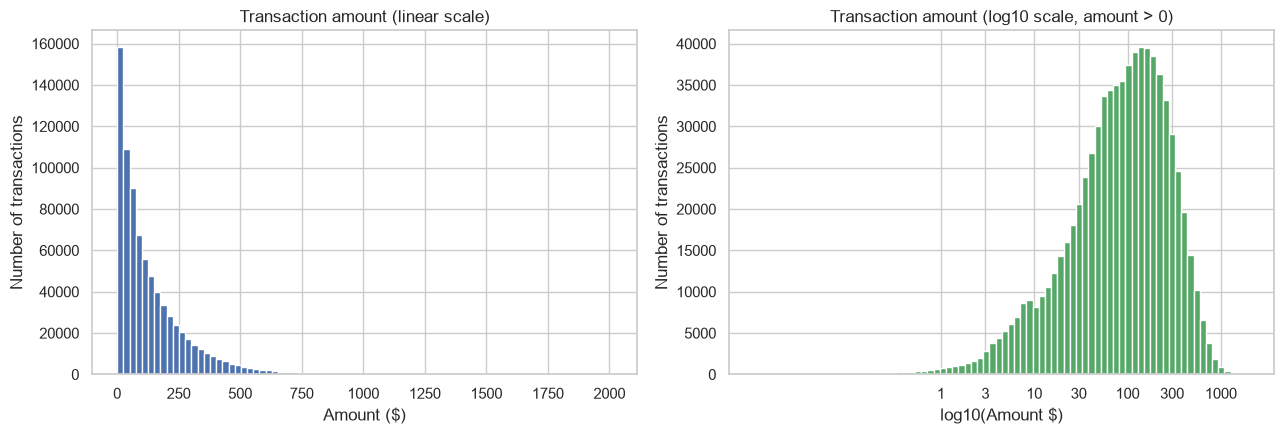

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(amt, bins=80, color="#4C72B0")
axes[0].set_title("Transaction amount (linear scale)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Number of transactions")

positive = amt[amt > 0]
axes[1].hist(np.log10(positive), bins=80, color="#55A868")
axes[1].set_title("Transaction amount (log10 scale, amount > 0)")
axes[1].set_xlabel("log10(Amount $)")
axes[1].set_ylabel("Number of transactions")
tick_locs = np.log10([1, 3, 10, 30, 100, 300, 1000])
axes[1].set_xticks(tick_locs)
axes[1].set_xticklabels([1, 3, 10, 30, 100, 300, 1000])

fig.tight_layout()
plt.show()


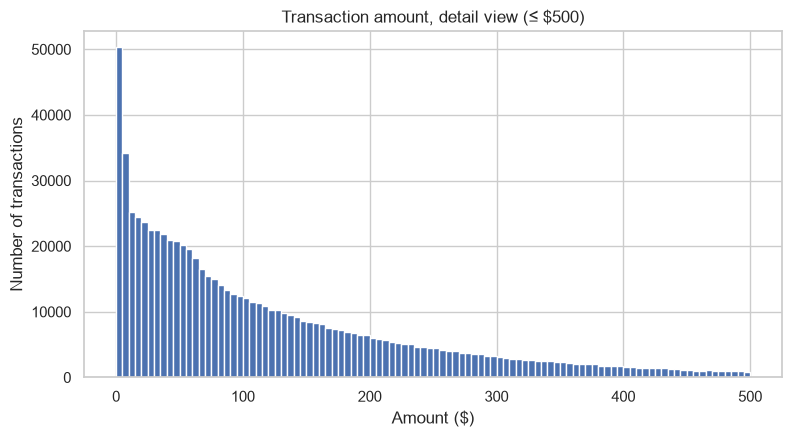

In [17]:
# A finer view of the bulk of the distribution: amounts up to $500.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(amt[amt <= 500], bins=100, color="#4C72B0")
ax.set_title("Transaction amount, detail view (\u2264 $500)")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Number of transactions")
plt.show()


**Finding - spending pattern.** A typical transaction is small: the median
is about **$88** and three quarters of transactions are under **$192**. The
largest single transaction is about **$2,012**. Around **22,000 transactions are
exactly $0**, and almost all of those are the address verification checks, not
real purchases. On the log-scale chart the distribution looks roughly bell
shaped, which confirms the amounts are close to log-normal. That is a useful fact
for later: a log transform of the amount is likely to help the model.


## 7. The target: how rare is fraud

The label to predict is `isFraud`. Before any modeling, it is worth seeing how
balanced it is.


In [18]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean()
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.2%}  ({fraud_counts.get(True, 0):,} of {len(df):,} transactions)")


isFraud
False    773946
True      12417
Name: count, dtype: int64

Fraud rate: 1.58%  (12,417 of 786,363 transactions)


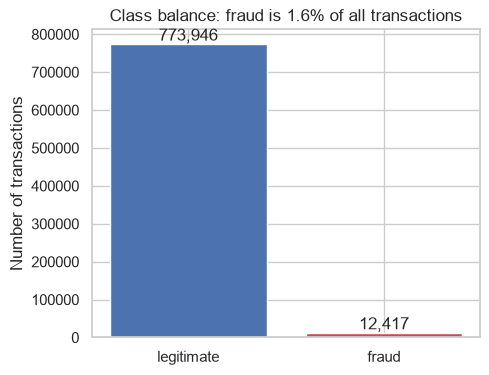

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["legitimate", "fraud"],
       [fraud_counts.get(False, 0), fraud_counts.get(True, 0)],
       color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of transactions")
ax.set_title(f"Class balance: fraud is {fraud_rate:.1%} of all transactions")
for i, v in enumerate([fraud_counts.get(False, 0), fraud_counts.get(True, 0)]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.show()


In [20]:
# Does fraud rate vary by a couple of obvious cuts?
by_type = df.groupby("transactionType")["isFraud"].mean().mul(100).round(2)
by_present = df.groupby("cardPresent")["isFraud"].mean().mul(100).round(2)
by_cat = df.groupby("merchantCategoryCode")["isFraud"].mean().mul(100).round(2).sort_values(ascending=False)
print("Fraud rate (%) by transactionType:\n", by_type, "\n")
print("Fraud rate (%) by cardPresent:\n", by_present, "\n")
print("Fraud rate (%) by merchantCategoryCode (top 8):\n", by_cat.head(8))


Fraud rate (%) by transactionType:
 transactionType
                        2.01
ADDRESS_VERIFICATION    0.58
PURCHASE                1.60
REVERSAL                1.66
Name: isFraud, dtype: float64 

Fraud rate (%) by cardPresent:
 cardPresent
False    2.07
True     0.98
Name: isFraud, dtype: float64 

Fraud rate (%) by merchantCategoryCode (top 8):
 merchantCategoryCode
airline          3.46
rideshare        2.49
online_retail    2.44
online_gifts     2.42
furniture        1.39
food             1.34
auto             1.26
entertainment    1.20
Name: isFraud, dtype: float64


**Finding - fraud is rare and uneven.** Only **1.58% of transactions are
fraud** (12,417 out of 786,363). Any model has to be judged with that in mind: a
model that simply calls everything legitimate would be 98.4% accurate and
completely useless, which is why the modeling notebook uses precision, recall,
and PR-AUC instead of accuracy.

Fraud is also not spread evenly. It is far more common when the card is **not
physically present**, and it clusters in a few merchant categories such as online
retail and rideshare. Those splits hint at features that should help the model.


## 8. Save a fast-loading copy for later notebooks

The raw file is a 610 MB text file and slow to parse. This writes a compact
Parquet copy into `data/raw/` (also gitignored) that notebooks 02 and 03 can load
in a second or two. The download and parse steps above remain the source of
truth.


In [21]:
CACHE_PATH = RAW_DIR / "transactions.parquet"
df.to_parquet(CACHE_PATH, index=False)
print(f"Wrote {CACHE_PATH.name} ({CACHE_PATH.stat().st_size:,} bytes)")


Wrote transactions.parquet (20,501,803 bytes)


## Summary for a non-technical reader

- The dataset is **786,363 synthetic credit card transactions** from **5,000
  accounts** over the **2016 calendar year**, published by Capital One for a data
  science exercise.
- The data is **clean on the surface**: no missing numbers. But six fields are
  empty on every row and carry no information, and a handful of fields are blank
  on a very small share of rows.
- **Most transactions are small.** Half are under about $88. A small number are
  address verification checks worth $0.
- Two kinds of duplicate-looking activity are visible in the transaction type
  field: **reversals** (a purchase undone) and repeated identical charges
  (**multi-swipes**). These are handled in the next notebook.
- **Fraud is rare: about 1.6% of transactions.** It is more common for
  card-not-present transactions and in certain merchant categories. Because it is
  so rare, model quality will be measured with fraud-focused metrics, not plain
  accuracy.

**Next:** `02_data_wrangling.ipynb` identifies and removes reversed and
multi-swipe duplicate transactions.
